## Section 1: Setup & Raw Load

In [ ]:
# imports
import pandas as pd
import numpy as np
import ast
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# load csv, fix bom, strip column names
df = pd.read_csv('resume_data.csv')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)

# drop duplicate column
df = df.drop(columns=['responsibilities.1'])

# rename typo columns
df = df.rename(columns={
    'educationaL_requirements': 'educational_requirements',
    'experiencere_requirement': 'experience_requirement',
    'related_skils_in_job': 'related_skills_in_job',
})

# lowercase + strip all string values
df = df.map(lambda x: x.strip().lower() if isinstance(x, str) else x)

print(f"loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"columns: {list(df.columns)}")

loaded: 9544 rows, 34 columns
columns: ['address', 'career_objective', 'skills', 'educational_institution_name', 'degree_names', 'passing_years', 'educational_results', 'result_types', 'major_field_of_studies', 'professional_company_names', 'company_urls', 'start_dates', 'end_dates', 'related_skills_in_job', 'positions', 'locations', 'responsibilities', 'extra_curricular_activity_types', 'extra_curricular_organization_names', 'extra_curricular_organization_links', 'role_positions', 'languages', 'proficiency_levels', 'certification_providers', 'certification_skills', 'online_links', 'issue_dates', 'expiry_dates', 'job_position_name', 'educational_requirements', 'experience_requirement', 'age_requirement', 'skills_required', 'matched_score']


## Section 2: Placeholder-to-Null Normalization

Many columns use placeholder values like `n/a`, `[none]`, `'company name'`, `'city, state'` instead of proper nulls. We normalize all of these to `NaN` so missingness is accurately represented.

In [5]:
# global placeholder replacements
df = df.replace({'': None, 'n/a': None, 'none': None, '[none]': None, '[]': None})

# regex: lists containing only n/a, none, or empty strings
# matches patterns like "['n/a', 'n/a']", "[none, none, none]", "['none', 'none']"
na_list_pattern = re.compile(
    r"^\[[\s'\"]*(?:n/a|none|)[\s'\"]*(?:,[\s'\"]*(?:n/a|none|)[\s'\"]*)*\]$"
)

for col in df.select_dtypes(include='object').columns:
    mask = df[col].apply(lambda x: bool(na_list_pattern.match(str(x))) if pd.notna(x) else False)
    df.loc[mask, col] = None

print(f"after global placeholder cleanup:")

after global placeholder cleanup:


C:\Users\tksjo\AppData\Local\Temp\ipykernel_32140\383806236.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [6]:
# column-specific: professional_company_names with only 'company name' entries
company_placeholder = re.compile(
    r"^\[[\s'\"]*company name[\s'\"]*(?:,[\s'\"]*company name[\s'\"]*)*\]$"
)
mask = df['professional_company_names'].apply(
    lambda x: bool(company_placeholder.match(str(x))) if pd.notna(x) else False
)
df.loc[mask, 'professional_company_names'] = None
print(f"professional_company_names: nullified {mask.sum()} placeholder rows")

# column-specific: locations with only 'city, state' entries
location_placeholder = re.compile(
    r"^\[[\s'\"]*city,?\s*state[\s'\"]*(?:,[\s'\"]*city,?\s*state[\s'\"]*)*\]$"
)
mask = df['locations'].apply(
    lambda x: bool(location_placeholder.match(str(x))) if pd.notna(x) else False
)
df.loc[mask, 'locations'] = None
print(f"locations: nullified {mask.sum()} placeholder rows")

professional_company_names: nullified 3882 placeholder rows
locations: nullified 2106 placeholder rows


In [7]:
# display updated missingness table
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
print(missing_df)

                                     missing_count  missing_pct
extra_curricular_organization_links           9544        100.0
online_links                                  9544        100.0
company_urls                                  9516         99.7
expiry_dates                                  9404         98.5
proficiency_levels                            8956         93.8
issue_dates                                   8936         93.6
languages                                     8844         92.7
address                                       8760         91.8
certification_skills                          8704         91.2
certification_providers                       8208         86.0
result_types                                  7966         83.5
educational_results                           7546         79.1
extra_curricular_organization_names           7098         74.4
role_positions                                6958         72.9
locations                               

## Section 3: Column Selection

Drop columns with >80% missing or that are structurally useless (URLs, dates, etc.). Keep `career_objective` (50.3% missing) and `extra_curricular_activity_types` (64.1%) as they contain useful text/categorical data.

In [8]:
# columns to drop (>80% missing or structurally useless)
drop_cols = [
    'languages', 'proficiency_levels', 'address',
    'expiry_dates', 'issue_dates', 'online_links',
    'certification_skills', 'certification_providers',
    'company_urls', 'educational_results', 'result_types',
    'extra_curricular_organization_links',
    'start_dates', 'end_dates',
]

df = df.drop(columns=drop_cols)
print(f"dropped {len(drop_cols)} columns, {df.shape[1]} remaining")

dropped 14 columns, 20 remaining


In [9]:
# summary of remaining columns
side_map = {
    'career_objective': 'resume', 'skills': 'resume',
    'educational_institution_name': 'resume', 'degree_names': 'resume',
    'passing_years': 'resume', 'major_field_of_studies': 'resume',
    'professional_company_names': 'resume', 'positions': 'resume',
    'locations': 'resume', 'responsibilities': 'resume',
    'related_skills_in_job': 'resume',
    'extra_curricular_activity_types': 'resume',
    'extra_curricular_organization_names': 'resume',
    'role_positions': 'resume',
    'job_position_name': 'job', 'educational_requirements': 'job',
    'experience_requirement': 'job', 'age_requirement': 'job',
    'skills_required': 'job',
    'matched_score': 'target',
}

summary = pd.DataFrame({
    'null_pct': (df.isnull().sum() / len(df) * 100).round(1),
    'nunique': df.nunique(),
    'side': pd.Series(side_map),
})
print(summary.to_string())

                                     null_pct  nunique    side
age_requirement                          42.8       14     job
career_objective                         50.3      171  resume
degree_names                              1.2      176  resume
educational_institution_name              1.2      324  resume
educational_requirements                  0.0       20     job
experience_requirement                   14.3       17     job
extra_curricular_activity_types          66.7       83  resume
extra_curricular_organization_names      74.4       84  resume
job_position_name                         0.0       28     job
locations                                69.1       67  resume
major_field_of_studies                   10.9      202  resume
matched_score                             0.0      345  target
passing_years                            12.9      141  resume
positions                                 1.5      298  resume
professional_company_names               42.4      188 

## Section 4: Parse List-as-String Columns

Many columns store Python lists as strings (e.g. `"['python', 'mysql']"`). We parse these into actual Python lists and filter out remaining placeholder elements.

In [10]:
# safe parser for list-as-string columns
PLACEHOLDER_VALS = {'n/a', 'none', 'n/ a', '', 'company name', 'city, state'}

def parse_list_string(val):
    """Parse a string representation of a list into an actual list.
    Filters out placeholder elements. Returns None if empty or all placeholders."""
    if pd.isna(val):
        return None

    val = str(val).strip()

    # try ast.literal_eval first
    try:
        parsed = ast.literal_eval(val)
        if isinstance(parsed, list):
            cleaned = [str(x).strip() for x in parsed
                       if str(x).strip().lower() not in PLACEHOLDER_VALS]
            return cleaned if cleaned else None
    except (ValueError, SyntaxError):
        pass

    # fallback: regex to extract items from bracket-delimited string
    if val.startswith('[') and val.endswith(']'):
        inner = val[1:-1]
        items = re.split(r',\s*', inner)
        cleaned = [x.strip().strip("'\"") for x in items
                   if x.strip().strip("'\"").lower() not in PLACEHOLDER_VALS]
        return cleaned if cleaned else None

    return None

In [11]:
# apply parser to all list-as-string columns
list_columns = [
    'skills', 'educational_institution_name', 'degree_names',
    'passing_years', 'major_field_of_studies', 'professional_company_names',
    'related_skills_in_job', 'positions', 'locations',
    'extra_curricular_activity_types', 'extra_curricular_organization_names',
    'role_positions',
]

for col in list_columns:
    df[col] = df[col].apply(parse_list_string)

# show sample parsed values
for col in list_columns:
    sample = df[col].dropna().iloc[0] if df[col].notna().any() else None
    print(f"{col}: {sample}")

skills: ['big data', 'hadoop', 'hive', 'python', 'mapreduce', 'spark', 'java', 'machine learning', 'cloud', 'hdfs', 'yarn', 'core java', 'data science', 'c++', 'data structures', 'dbms', 'rdbms', 'informatica', 'talend', 'amazon redshift', 'microsoft azure']
educational_institution_name: ['the amity school of engineering & technology (aset), noida']
degree_names: ['b.tech']
passing_years: ['2019']
major_field_of_studies: ['electronics']
professional_company_names: ['coca-cola']
related_skills_in_job: ["['big data']"]
positions: ['big data analyst']
locations: ['san jose, ca', 'milpitas, ca']
extra_curricular_activity_types: ['professional organization', 'honor society', 'honor society', 'honor society']
extra_curricular_organization_names: ['ohio society of cpas', 'beta alpha psi', 'golden key international honour society', 'beta gamma sigma']
role_positions: ['silver medal for economics junior award', 'finalist at business solution pan india', 'winner and runner-up for 2018 and 2019 r

In [12]:
# re-check null percentages after parsing
post_parse_null = (df.isnull().sum() / len(df) * 100).round(1)
print("null % after parsing list columns:")
print(post_parse_null.sort_values(ascending=False).to_string())

null % after parsing list columns:
extra_curricular_organization_names    74.4
role_positions                         72.9
locations                              70.5
extra_curricular_activity_types        66.7
career_objective                       50.3
professional_company_names             43.9
age_requirement                        42.8
skills_required                        17.8
experience_requirement                 14.3
related_skills_in_job                  13.5
passing_years                          12.9
major_field_of_studies                 10.9
positions                               1.5
degree_names                            1.2
skills                                  1.2
educational_institution_name            1.2
responsibilities                        0.0
job_position_name                       0.0
educational_requirements                0.0
matched_score                           0.0


## Section 5: Feature Engineering

Extract structured numeric features (counts, years, skill overlap) and build clean text columns that separate resume-side vs job-side content.

In [13]:
# count features from parsed lists
df['num_skills'] = df['skills'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['num_degrees'] = df['degree_names'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['num_positions'] = df['positions'].apply(lambda x: len(x) if isinstance(x, list) else 0)
df['num_institutions'] = df['educational_institution_name'].apply(lambda x: len(x) if isinstance(x, list) else 0)

print("count feature stats:")
print(df[['num_skills', 'num_degrees', 'num_positions', 'num_institutions']].describe().round(1))

count feature stats:
       num_skills  num_degrees  num_positions  num_institutions
count      9544.0       9544.0         9544.0            9544.0
mean         21.6          1.6            2.7               1.6
std          19.3          1.0            2.0               1.0
min           0.0          0.0            0.0               0.0
25%          10.0          1.0            1.0               1.0
50%          14.0          1.0            2.0               1.0
75%          29.0          2.0            4.0               2.0
max         144.0         11.0           10.0              11.0


In [14]:
# extract experience_years from experience_requirement
def extract_experience_years(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'(\d+)\s*year', str(val))
    return float(match.group(1)) if match else np.nan

df['experience_years'] = df['experience_requirement'].apply(extract_experience_years)

# extract age_min and age_max from age_requirement
def extract_age_range(val):
    if pd.isna(val):
        return np.nan, np.nan
    match = re.search(r'age\s*(\d+)\s*to\s*(\d+)', str(val))
    if match:
        return float(match.group(1)), float(match.group(2))
    return np.nan, np.nan

df[['age_min', 'age_max']] = df['age_requirement'].apply(
    lambda x: pd.Series(extract_age_range(x))
)

print(f"experience_years: {df['experience_years'].notna().sum()} non-null")
print(f"age_min/age_max: {df['age_min'].notna().sum()} non-null")

experience_years: 8180 non-null
age_min/age_max: 3411 non-null


In [15]:
# skill_jaccard: jaccard similarity between resume skills and job skills_required
def skill_jaccard(resume_skills, job_skills_text):
    """Compute Jaccard similarity between resume skill list and job skills_required text."""
    if not isinstance(resume_skills, list) or pd.isna(job_skills_text):
        return 0.0
    resume_set = set(s.lower().strip() for s in resume_skills)
    # tokenize job skills by splitting on common delimiters
    job_tokens = set(re.split(r'[,\s]+', str(job_skills_text).lower().strip()))
    job_tokens.discard('')
    if not resume_set or not job_tokens:
        return 0.0
    intersection = resume_set & job_tokens
    union = resume_set | job_tokens
    return len(intersection) / len(union) if union else 0.0

df['skill_jaccard'] = df.apply(
    lambda row: skill_jaccard(row['skills'], row['skills_required']), axis=1
)

print(f"skill_jaccard stats:")
print(df['skill_jaccard'].describe().round(3))

skill_jaccard stats:
count    9544.000
mean        0.003
std         0.015
min         0.000
25%         0.000
50%         0.000
75%         0.000
max         0.273
Name: skill_jaccard, dtype: float64


In [16]:
# helper to join list or string fields into text
def join_field(val):
    """Join a list into space-separated string, or return string as-is."""
    if isinstance(val, list):
        return ' '.join(str(x) for x in val)
    if pd.notna(val):
        return str(val)
    return ''

# build resume_text: career_objective + skills + degree_names + major_field_of_studies + positions + responsibilities
df['resume_text'] = (
    df['career_objective'].fillna('') + ' ' +
    df['skills'].apply(join_field) + ' ' +
    df['degree_names'].apply(join_field) + ' ' +
    df['major_field_of_studies'].apply(join_field) + ' ' +
    df['positions'].apply(join_field) + ' ' +
    df['responsibilities'].fillna('')
)

# build job_text: job_position_name + educational_requirements + experience_requirement + skills_required
df['job_text'] = (
    df['job_position_name'].fillna('') + ' ' +
    df['educational_requirements'].fillna('') + ' ' +
    df['experience_requirement'].fillna('') + ' ' +
    df['skills_required'].fillna('')
)

# combined_text for simple models
df['combined_text'] = df['resume_text'] + ' ' + df['job_text']

# collapse whitespace
for col in ['resume_text', 'job_text', 'combined_text']:
    df[col] = df[col].str.strip().str.replace(r'\s+', ' ', regex=True)
    # replace empty strings with None
    df[col] = df[col].replace('', None)

print(f"resume_text null: {df['resume_text'].isnull().sum()}")
print(f"job_text null: {df['job_text'].isnull().sum()}")
print(f"combined_text null: {df['combined_text'].isnull().sum()}")
print(f"\nsample resume_text:\n{df['resume_text'].iloc[0][:200]}...")
print(f"\nsample job_text:\n{df['job_text'].iloc[0][:200]}...")

resume_text null: 0
job_text null: 0
combined_text null: 0

sample resume_text:
big data analytics working and database warehouse manager with robust experience in handling all kinds of data. i have also used multiple cloud infrastructure services and am well acquainted with them...

sample job_text:
senior software engineer b.sc in computer science & engineering from a reputed university. at least 1 year...


## Section 6: Target Variable Analysis

Examine the distribution and correlations of `matched_score` to validate that it's well-behaved as a regression target.

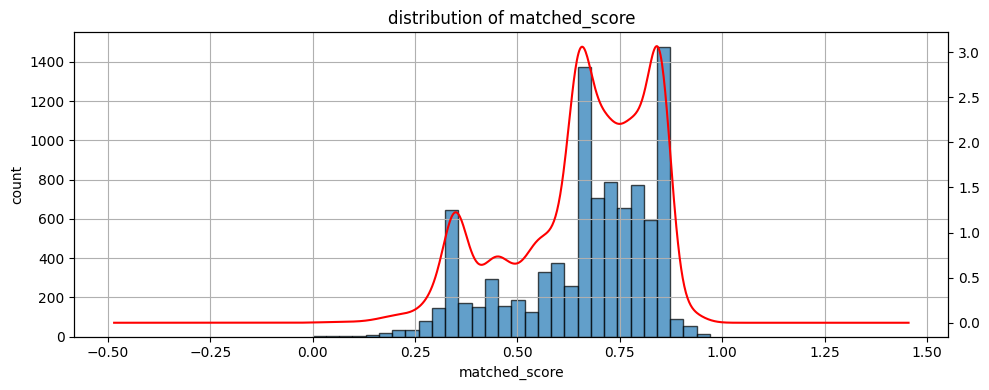


matched_score stats:
count    9544.000
mean        0.661
std         0.167
min         0.000
25%         0.583
50%         0.683
75%         0.793
max         0.970
Name: matched_score, dtype: float64
skewness: -0.800

top 5 value counts:
matched_score
0.850000    1470
0.650000    1321
0.716667     516
0.683333     483
0.750000     452
Name: count, dtype: int64


In [26]:
# histogram + kde of matched_score
from scipy.stats import gaussian_kde

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
df['matched_score'].hist(bins=30, ax=ax, alpha=0.7, edgecolor='black')
df['matched_score'].plot.kde(ax=ax, secondary_y=True, color='red')
ax.set_xlabel('matched_score')
ax.set_ylabel('count')
ax.set_title('distribution of matched_score')
plt.tight_layout()
plt.show()

# stats
print(f"\nmatched_score stats:")
print(df['matched_score'].describe().round(3))
print(f"skewness: {df['matched_score'].skew():.3f}")
print(f"\ntop 5 value counts:")
print(df['matched_score'].value_counts().head(5))

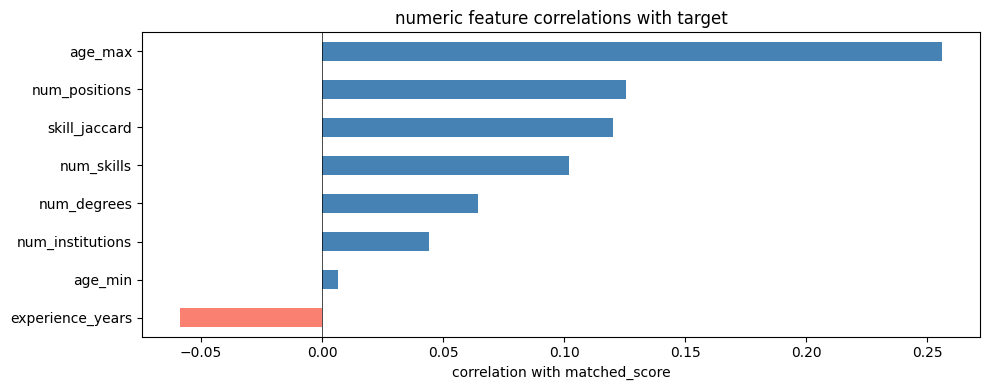


correlation values:
experience_years   -0.059
age_min             0.007
num_institutions    0.044
num_degrees         0.064
num_skills          0.102
skill_jaccard       0.120
num_positions       0.125
age_max             0.256


In [18]:
# correlation of numeric features with matched_score
numeric_features = ['num_skills', 'num_degrees', 'num_positions', 'num_institutions',
                    'experience_years', 'age_min', 'age_max', 'skill_jaccard']

correlations = df[numeric_features + ['matched_score']].corr()['matched_score'].drop('matched_score').sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
correlations.plot.barh(ax=ax, color=['salmon' if x < 0 else 'steelblue' for x in correlations])
ax.set_xlabel('correlation with matched_score')
ax.set_title('numeric feature correlations with target')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

print("\ncorrelation values:")
print(correlations.round(3).to_string())

## Section 7: Final Assembly & Export

Select the final column set, run sanity checks, and save to `resume_data_cleaned.csv`.

In [19]:
# convert parsed list columns to JSON strings for CSV storage
def list_to_json(val):
    if isinstance(val, list):
        return json.dumps(val)
    return None

# select final columns
df_out = pd.DataFrame({
    'matched_score': df['matched_score'],
    'resume_text': df['resume_text'],
    'job_text': df['job_text'],
    'combined_text': df['combined_text'],
    'num_skills': df['num_skills'],
    'num_degrees': df['num_degrees'],
    'num_positions': df['num_positions'],
    'experience_years': df['experience_years'],
    'age_min': df['age_min'],
    'age_max': df['age_max'],
    'skill_jaccard': df['skill_jaccard'],
    'job_position_name': df['job_position_name'],
    'educational_requirements': df['educational_requirements'],
    'skills_required': df['skills_required'],
    'skills': df['skills'].apply(list_to_json),
    'degree_names': df['degree_names'].apply(list_to_json),
    'positions': df['positions'].apply(list_to_json),
})

print(f"final shape: {df_out.shape}")
print(f"\ncolumn types:")
print(df_out.dtypes)

final shape: (9544, 17)

column types:
matched_score               float64
resume_text                     str
job_text                        str
combined_text                   str
num_skills                    int64
num_degrees                   int64
num_positions                 int64
experience_years            float64
age_min                     float64
age_max                     float64
skill_jaccard               float64
job_position_name               str
educational_requirements        str
skills_required                 str
skills                          str
degree_names                    str
positions                       str
dtype: object


In [20]:
# sanity checks
print("=== sanity checks ===")
print(f"matched_score nulls: {df_out['matched_score'].isnull().sum()}")
print(f"combined_text nulls: {df_out['combined_text'].isnull().sum()}")
print(f"resume_text nulls: {df_out['resume_text'].isnull().sum()}")
print(f"job_text nulls: {df_out['job_text'].isnull().sum()}")
print(f"\nnull counts per column:")
print(df_out.isnull().sum().to_string())

# spot check a few rows
print(f"\n=== spot check (row 0) ===")
print(f"matched_score: {df_out['matched_score'].iloc[0]}")
print(f"skills: {df_out['skills'].iloc[0][:80] if pd.notna(df_out['skills'].iloc[0]) else None}...")
print(f"resume_text: {df_out['resume_text'].iloc[0][:120] if pd.notna(df_out['resume_text'].iloc[0]) else None}...")
print(f"job_text: {df_out['job_text'].iloc[0][:120] if pd.notna(df_out['job_text'].iloc[0]) else None}...")

=== sanity checks ===
matched_score nulls: 0
combined_text nulls: 0
resume_text nulls: 0
job_text nulls: 0

null counts per column:
matched_score                  0
resume_text                    0
job_text                       0
combined_text                  0
num_skills                     0
num_degrees                    0
num_positions                  0
experience_years            1364
age_min                     6133
age_max                     6133
skill_jaccard                  0
job_position_name              0
educational_requirements       0
skills_required             1701
skills                       112
degree_names                 112
positions                    140

=== spot check (row 0) ===
matched_score: 0.85
skills: ["big data", "hadoop", "hive", "python", "mapreduce", "spark", "java", "machine ...
resume_text: big data analytics working and database warehouse manager with robust experience in handling all kinds of data. i have a...
job_text: senior software engi

In [21]:
# save to csv
df_out.to_csv('resume_data_cleaned.csv', index=False)
print(f"saved resume_data_cleaned.csv ({df_out.shape[0]} rows, {df_out.shape[1]} columns)")

saved resume_data_cleaned.csv (9544 rows, 17 columns)
